In [27]:
#imports
import pandas as pd
from generate_schedule import generate_schedule
from sim_season import simulate_season
from random_fpi import make_random_fpi
from playoffs import playoff_field
from collections import Counter
from real_nfl_schedule import build_real_season_dfs,real_schedule_df
import matplotlib.pyplot as plt
from simulate_playoffs import simulate_playoffs
import nflreadpy as nfl
import numpy as np
from scipy.stats import linregress

First let's do 1000 sims on the same FPI and Schedule seed. The main thing I'm looking at is the breakdown of when the higher FPI wins.

In [28]:
# March 2
# Figure out if this is actually exponential normal variable
# Look at different distributions for FPI models (Ask)
# Look at longer seasons (Done)
# Best of 3,5,7 for playoffs
# Expand amount of teams
# Look for publishing/blog oppurtunties
# How fast does the longer season approach infinity
# Fraction of #1 = true #1
# Clipped net points/total margin (max{T,Margin}) - How low can you go with T?
# 

# March 9
# 

dfs = {}
for year in range(2015, 2025):
    dfs[year] = pd.read_csv(f"FPI_Years/FPI_{year}.csv")
    
team_to_abbr = {"Arizona Cardinals":"ARI",
    "Atlanta Falcons":"ATL",
    "Baltimore Ravens":"BAL",
    "Buffalo Bills":"BUF",
    "Carolina Panthers":"CAR",
    "Chicago Bears":"CHI",
    "Cincinnati Bengals":"CIN",
    "Cleveland Browns":"CLE",
    "Dallas Cowboys":"DAL",
    "Denver Broncos":"DEN",
    "Detroit Lions":"DET",
    "Green Bay Packers":"GB",
    "Houston Texans":"HOU",
    "Indianapolis Colts":"IND",
    "Jacksonville Jaguars":"JAX",
    "Kansas City Chiefs":"KC",
    "Las Vegas Raiders":"LV",
    "Los Angeles Chargers":"LAC",
    "Los Angeles Rams":"LA",
    "Miami Dolphins":"MIA",
    "Minnesota Vikings":"MIN",
    "New England Patriots":"NE",
    "New Orleans Saints":"NO",
    "New York Giants":"NYG",
    "New York Jets":"NYJ",
    "Philadelphia Eagles":"PHI",
    "Pittsburgh Steelers":"PIT",
    "San Francisco 49ers":"SF",
    "Seattle Seahawks":"SEA",
    "Tampa Bay Buccaneers":"TB",
    "Tennessee Titans":"TEN",
    "Washington Commanders":"WAS"
    }

corrected_teams = {"Oakland Raiders": "Las Vegas Raiders",
                   "St. Louis Rams": "Los Angeles Rams",
                   "San Diego Chargers": "Los Angeles Chargers"}

Counter({'head to head': 330, 'conference_record': 207, 'common_games': 89, 'division_record': 74, 'strength_of_victory': 43})
Counter({'higher FPI won': 375, 'lower FPI won': 368})
                       Playoff_percentage  Playoff_Percentage  FPI
Team                                                              
Jacksonville Jaguars                   99                0.99  4.9
Cincinatti Bengals                     97                0.97  4.8
Green Bay Packers                      93                0.93  3.4
Philadelphia Eagles                    83                0.83  1.2
San Francisco 49ers                    82                0.82  2.2
Arizona Cardinals                      75                0.75  2.5
Denver Broncos                         71                0.71  0.8
Washington Commanders                  70                0.70  1.6
New York Jets                          67                0.67 -0.5
Carolina Panthers                      64                0.64  1.2
New Orleans Sa

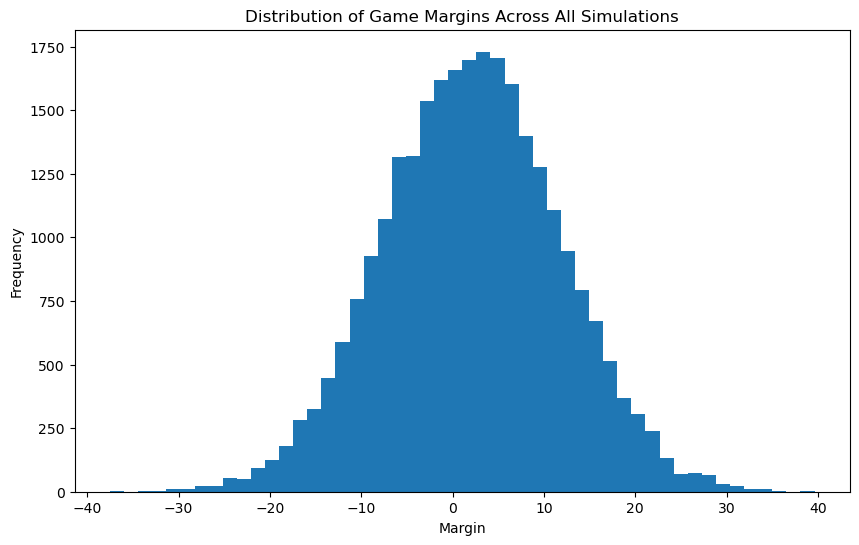

In [29]:
# Better tiebreaking procedures
# 1000 sims on the same FPI/Schedule seed
n = 100

df = pd.read_csv("FPI-1-11-26.csv")
df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=5)
schedule_df = generate_schedule(df_seeded, seed=1)

tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()
for sim_seed in range(1, n + 1):
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))


print(tb_counts)
print(fpi_counts)
#print(field_count)

field_prob_df = (pd.Series(field_count).sort_values(ascending=False).rename("Playoff_percentage").to_frame())

field_prob_df["Playoff_Percentage"] = field_prob_df["Playoff_percentage"]/n
field_prob_df = field_prob_df.merge(df_seeded[["Team", "FPI"]],left_index=True,right_on="Team",how="left").set_index("Team")

print(field_prob_df)

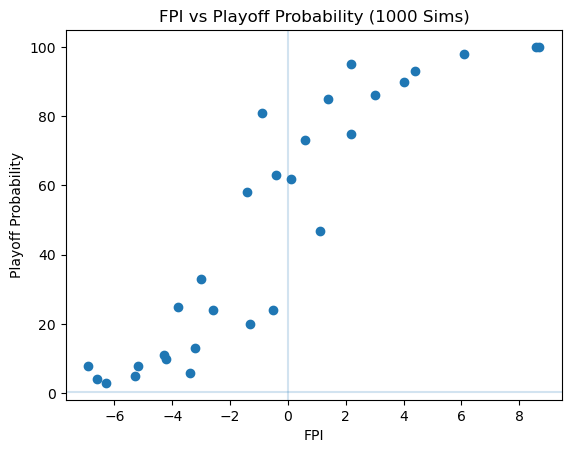

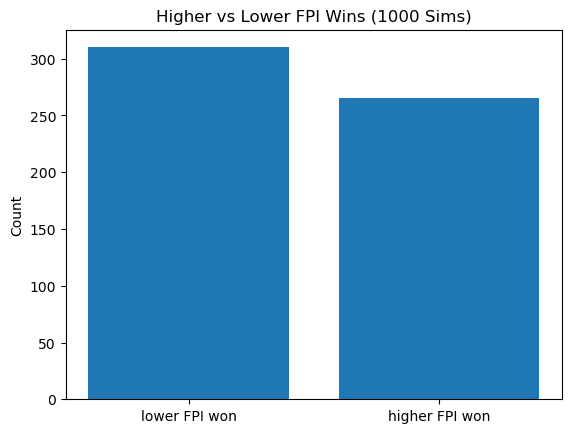

In [24]:
plt.scatter(field_prob_df["FPI"], field_prob_df["Playoff_percentage"])

plt.xlabel("FPI")
plt.ylabel("Playoff Probability")
plt.title("FPI vs Playoff Probability (1000 Sims)")
plt.axhline(0.5,alpha = 0.2)
plt.axvline(0,alpha=0.2)

plt.show()

fpi_hist_df = (pd.Series(fpi_counts))

plt.figure()
plt.bar(fpi_hist_df.index, fpi_hist_df.values)
plt.ylabel("Count")
plt.title("Higher vs Lower FPI Wins (1000 Sims)")
plt.show()

Now that we see that tiebreakers aren't really promoting the true "best" team, let's see what it looks like if we ran the same sim but with a new tiebreaker, which will be set in playoffs.py. This custom tiebreaker is simply point differential.

In [25]:
# Better tiebreaking procedures
# 1000 sims on the same FPI/Schedule seed
n = 1000

df = pd.read_csv("FPI-1-11-26.csv")
df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=5)
schedule_df = generate_schedule(df_seeded, seed=1)

tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

for sim_seed in range(1, n + 1):
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df, mode = "total_margin") #tie_breaker is just point differential

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))


print(tb_counts)
print(fpi_counts)
#print(field_count)

field_prob_df = (pd.Series(field_count).sort_values(ascending=False).rename("playoff_percentage").to_frame())

field_prob_df["Playoff_Percentage"] = field_prob_df["playoff_percentage"]/n
field_prob_df = field_prob_df.merge(df_seeded[["Team", "FPI"]],left_index=True,right_on="Team",how="left").set_index("Team")

print(field_prob_df)

Counter({'total_margin': 5552})
Counter({'higher FPI won': 3864, 'lower FPI won': 1688})
                       playoff_percentage  Playoff_Percentage  FPI
Team                                                              
Cincinatti Bengals                   1000               1.000  8.5
Jacksonville Jaguars                 1000               1.000  8.6
Green Bay Packers                     985               0.985  6.0
Arizona Cardinals                     981               0.981  4.4
Philadelphia Eagles                   943               0.943  2.2
San Francisco 49ers                   941               0.941  4.0
Washington Commanders                 913               0.913  2.9
Denver Broncos                        890               0.890  1.4
Carolina Panthers                     788               0.788  2.2
New York Jets                         774               0.774 -0.9
Baltimore Ravens                      743               0.743  0.6
Cleveland Browns                      65

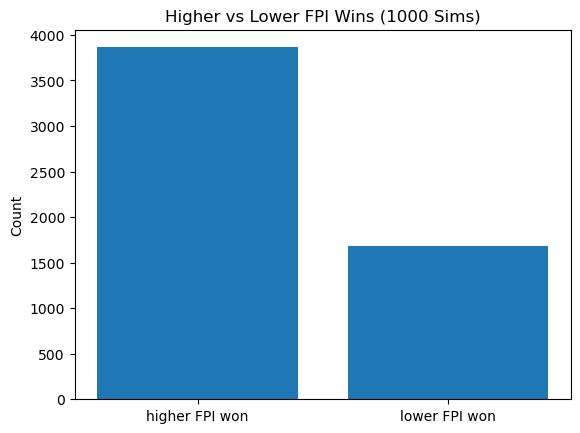

In [26]:
fpi_hist_df = (pd.Series(fpi_counts))

plt.figure()
plt.bar(fpi_hist_df.index, fpi_hist_df.values)
plt.ylabel("Count")
plt.title("Higher vs Lower FPI Wins (1000 Sims)")
plt.show()

In [26]:
# Better tiebreaking procedures
# 1000 sims on the same FPI/Schedule seed
n = 1000

df = pd.read_csv("FPI-1-11-26.csv")
df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=5)
schedule_df = generate_schedule(df_seeded, seed=1)

tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

for sim_seed in range(1, n + 1):
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed, tm_cap = 14)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df, mode = "capped_margin") 

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))


print(tb_counts)
print(fpi_counts)
#print(field_count)

field_prob_df = (pd.Series(field_count).sort_values(ascending=False).rename("playoff_percentage").to_frame())

field_prob_df["Playoff_Percentage"] = field_prob_df["playoff_percentage"]/n
field_prob_df = field_prob_df.merge(df_seeded[["Team", "FPI"]],left_index=True,right_on="Team",how="left").set_index("Team")

print(field_prob_df)

Counter({'luke_formula': 8245})
Counter({'higher FPI won': 5198, 'lower FPI won': 3047})
                       playoff_percentage  Playoff_Percentage  FPI
Team                                                              
Jacksonville Jaguars                  975               0.975  4.1
Cincinatti Bengals                    943               0.943  4.0
Green Bay Packers                     885               0.885  2.8
Arizona Cardinals                     818               0.818  2.1
San Francisco 49ers                   800               0.800  1.9
Philadelphia Eagles                   743               0.743  1.0
Washington Commanders                 733               0.733  1.4
Denver Broncos                        684               0.684  0.7
Carolina Panthers                     642               0.642  1.0
New York Jets                         614               0.614 -0.4
Baltimore Ravens                      571               0.571  0.3
New Orleans Saints                    50

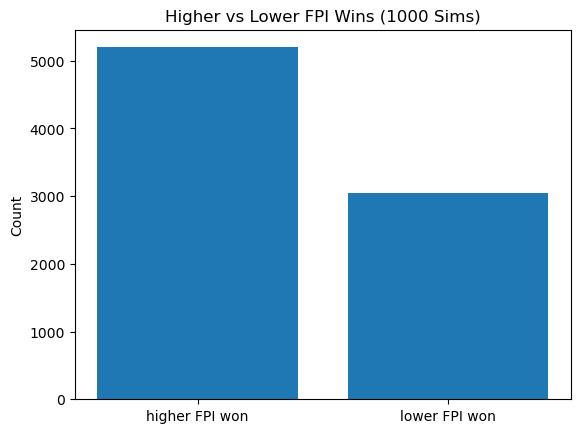

In [27]:
fpi_hist_df = (pd.Series(fpi_counts))

plt.figure()
plt.bar(fpi_hist_df.index, fpi_hist_df.values)
plt.ylabel("Count")
plt.title("Higher vs Lower FPI Wins (1000 Sims)")
plt.show()

In [28]:
# How well does an FPI based model predict playoffs?
for year in range(2015, 2025):
    schedule = real_schedule_df(year)
    schedule["Home"] = schedule["Home"].replace(corrected_teams)
    schedule["Away"] = schedule["Away"].replace(corrected_teams)

    dfs[year]["Team"] = dfs[year]["Team"].replace(corrected_teams).copy()
    field_count = Counter()
    n = 300
    for sim_seed in range(1, n + 1):
        results, standings = simulate_season(dfs[year],schedule,seed = sim_seed)
        field, tiebreakers, fpi = playoff_field(standings,results)
        field_count.update(Counter(field["Team"]))
    
    # load schedules
    sched = nfl.load_schedules([year]).to_pandas()
    
    # keep only playoff games
    playoffs = sched[sched["game_type"] != "REG"]
    
    # get unique teams that played in playoffs
    playoff_teams = set(playoffs["home_team"]).union(set(playoffs["away_team"]))
    #print(playoff_teams)
    
    field_prob_df = (pd.Series(field_count).sort_values(ascending=False).rename("playoff_percentage").to_frame())
    
    field_prob_df["playoff_percentage"] = field_prob_df["playoff_percentage"]/n
    field_prob_df = field_prob_df.merge(dfs[year][["Team", "FPI"]],left_index=True,right_on="Team",how="left").set_index("Team")
    field_prob_df["abbr"] = field_prob_df.index.map(team_to_abbr)
    field_prob_df["Made_Playoffs"] = field_prob_df["abbr"].isin(playoff_teams).astype(int)
    field_prob_df["Rank"] = field_prob_df["playoff_percentage"].rank(ascending=False, method="first").astype(int)

    playoff_only_df = (field_prob_df[field_prob_df["Made_Playoffs"] == 1].sort_values("Rank"))
    k = field_prob_df["Made_Playoffs"].sum()
    ideal_mean = (k + 1) / 2
    actual_mean = field_prob_df[field_prob_df["Made_Playoffs"] == 1]["Rank"].mean()
    accuracy_score = ideal_mean / actual_mean
    
    print(year)
    print(playoff_only_df)
    print(accuracy_score)
    
    #print(field_prob_df)

2015
                       playoff_percentage  FPI abbr  Made_Playoffs  Rank
Team                                                                    
Carolina Panthers                1.000000  7.9  CAR              1     1
Seattle Seahawks                 1.000000  8.8  SEA              1     2
Arizona Cardinals                0.996667  8.3  ARI              1     3
New England Patriots             0.976667  7.2   NE              1     4
Pittsburgh Steelers              0.950000  7.1  PIT              1     5
Kansas City Chiefs               0.923333  6.8   KC              1     6
Denver Broncos                   0.880000  5.9  DEN              1     7
Green Bay Packers                0.823333  3.6   GB              1     9
Minnesota Vikings                0.756667  2.8  MIN              1    10
Houston Texans                   0.666667 -0.2  HOU              1    11
Cincinnati Bengals               0.663333  4.1  CIN              1    12
Washington Commanders            0.336667 -2.8

Coin flip! _________-----------_____________------------_______________-------- ['New Orleans Saints', 'Tampa Bay Buccaneers']


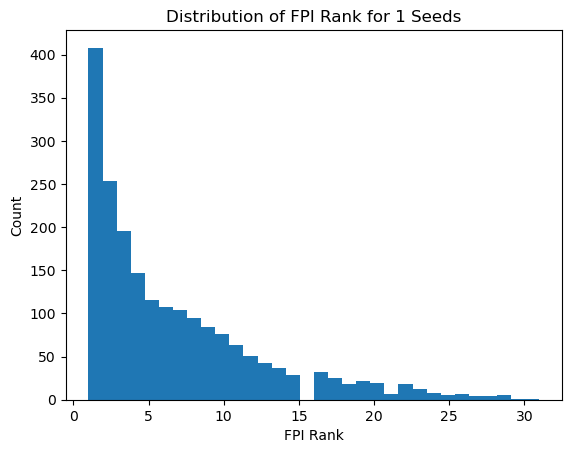

In [29]:
one_seed_ranks = []

n = 1000
for sim_seed in range(1, n + 1):

    df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)
    
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)

    one_seeds = field[field["Seed"] == 1]["Team"]

    # grab the rows for the 1 seeds
    one_seed_rows = standings_df.loc[standings_df["Team"].isin(one_seeds),["Team", "FPI_Rank"]].copy()

    one_seed_ranks.append(one_seed_rows) # store results

# combine all simulations
one_seed_ranks_df = pd.concat(one_seed_ranks, ignore_index=True)

plt.hist(one_seed_ranks_df["FPI_Rank"], bins=32)
plt.xlabel("FPI Rank")
plt.ylabel("Count")
plt.title("Distribution of FPI Rank for 1 Seeds")
plt.show()

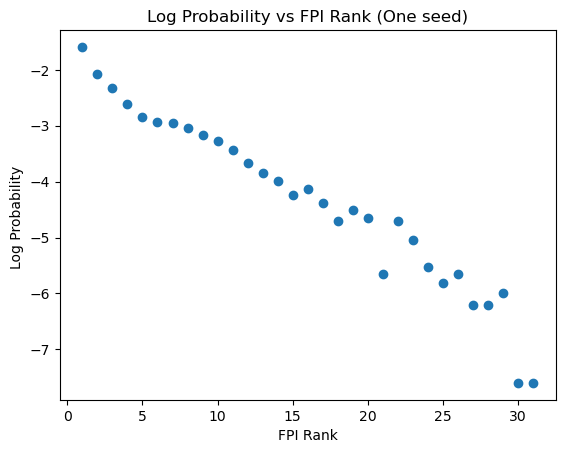

R^2 = 0.9523206200678996


In [30]:
rank_counts = one_seed_ranks_df["FPI_Rank"].value_counts().sort_index()
rank_probs = rank_counts / rank_counts.sum()

plt.scatter(rank_probs.index, np.log(rank_probs))
plt.xlabel("FPI Rank")
plt.ylabel("Log Probability ")
plt.title("Log Probability vs FPI Rank (One seed)")
plt.show()

slope, intercept, r, p, se = linregress(rank_probs.index, np.log(rank_probs))

print("R^2 =", r**2)

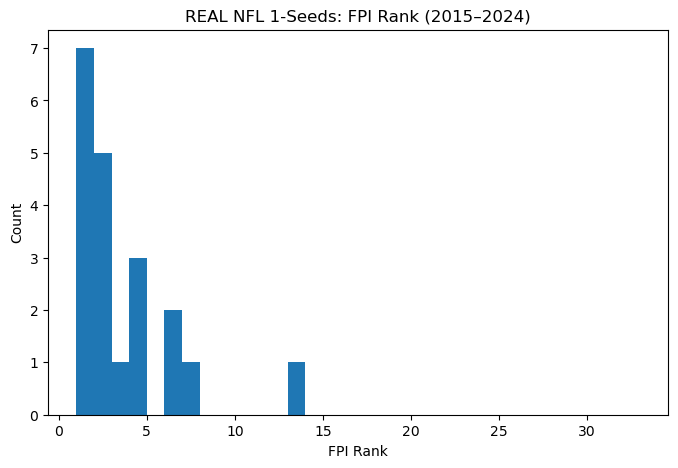

In [31]:
one_seed_fpi_history = []

for year in range(2015, 2025):
    results, standings = build_real_season_dfs(year)
    # replace all teams
    results["Home"]   = results["Home"].replace(corrected_teams)
    results["Away"]   = results["Away"].replace(corrected_teams)
    results["Winner"] = results["Winner"].replace(corrected_teams)
    results["Loser"]  = results["Loser"].replace(corrected_teams)
    standings["Team"] = standings["Team"].replace(corrected_teams)

    # replace FPI with CSV version
    standings = standings.drop(columns=["FPI"])
    standings = standings.merge(dfs[year][["Team", "FPI"]], on="Team", how="left")
    standings["FPI_Rank"] = standings["FPI"].rank(method="min", ascending=False).astype(int)
    
    field, tiebreakers, fpi_winners = playoff_field(standings, results)
    
    # grab the 1 seeds
    one_seeds = field.loc[field["Seed"] == 1, "Team"]

    rows = standings.loc[standings["Team"].isin(one_seeds), ["Team", "Conference", "FPI", "FPI_Rank"]].copy()
    rows["Year"] = year
    one_seed_fpi_history.append(rows)

one_seed_fpi_history_df = pd.concat(one_seed_fpi_history, ignore_index=True)
plt.figure(figsize=(8,5))
plt.hist(one_seed_fpi_history_df["FPI_Rank"], bins=range(1,34))
plt.xlabel("FPI Rank")
plt.ylabel("Count")
plt.title("REAL NFL 1-Seeds: FPI Rank (2015–2024)")
plt.show()

Coin flip! _________-----------_____________------------_______________-------- ['New Orleans Saints', 'Tampa Bay Buccaneers']


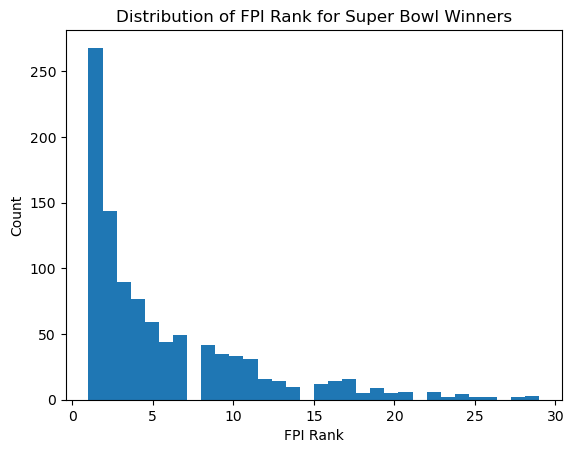

In [32]:
# How often does the best team win the Super Bowl
sb_winner_ranks = []

n = 1000
for sim_seed in range(1, n + 1):

    df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)

    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)

    # simulate playoffs and get super bowl champion
    playoff_results_df, sb_winner = simulate_playoffs(df_seeded, field, sigma=9, home_field=2, seed=sim_seed)

    # grab champion's FPI rank
    sb_row = standings_df.loc[standings_df["Team"] == sb_winner,["Team", "FPI_Rank"]].copy()

    # store results
    sb_winner_ranks.append(sb_row)

# combine all simulations
sb_winner_ranks_df = pd.concat(sb_winner_ranks, ignore_index=True)

plt.hist(sb_winner_ranks_df["FPI_Rank"], bins=32)
plt.xlabel("FPI Rank")
plt.ylabel("Count")
plt.title("Distribution of FPI Rank for Super Bowl Winners")
plt.show()

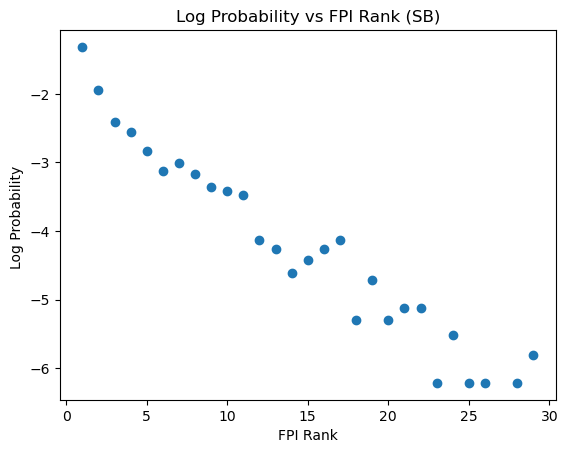

R^2 = 0.9411187287077499


In [33]:
rank_counts = sb_winner_ranks_df["FPI_Rank"].value_counts().sort_index()
rank_probs = rank_counts / rank_counts.sum()

plt.scatter(rank_probs.index, np.log(rank_probs))
plt.xlabel("FPI Rank")
plt.ylabel("Log Probability ")
plt.title("Log Probability vs FPI Rank (SB)")
plt.show()

slope, intercept, r, p, se = linregress(rank_probs.index, np.log(rank_probs))

print("R^2 =", r**2)

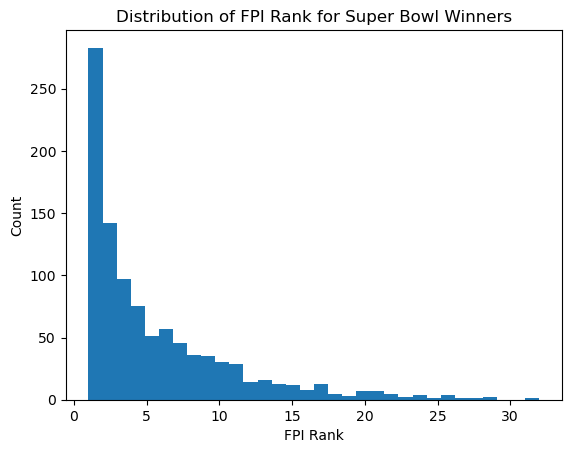

In [34]:
# How often does the best team win the Super Bowl (custom tiebreakers)
sb_winner_ranks = []

n = 1000
for sim_seed in range(1, n + 1):

    df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)

    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df, mode = "total_margin")

    # simulate playoffs and get champion
    playoff_results_df, sb_winner = simulate_playoffs(df_seeded, field, sigma=9, home_field=2, seed=sim_seed)

    # grab champion's FPI rank
    sb_row = standings_df.loc[standings_df["Team"] == sb_winner,["Team", "FPI_Rank"]].copy()

    # store results
    sb_winner_ranks.append(sb_row)

# combine all simulations
sb_winner_ranks_df = pd.concat(sb_winner_ranks, ignore_index=True)

plt.hist(sb_winner_ranks_df["FPI_Rank"], bins=32)
plt.xlabel("FPI Rank")
plt.ylabel("Count")
plt.title("Distribution of FPI Rank for Super Bowl Winners")
plt.show()

In [35]:
season_lengths = [12, 16, 17, 34, 50, 100, 250]
n_sims = 100

results = []

df = pd.read_csv("FPI-1-11-26.csv")

for season_length in season_lengths:
    
    fpi_win_corrs = []
    one_seed_fpi_ranks = []
    best_team_one_seed_count = 0
    best_team_sb_count = 0
    
    for sim_seed in range(1, n_sims + 1):
        
        df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=sim_seed)
        schedule_df = generate_schedule(df_seeded, seed=sim_seed, season_length=season_length)
        results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
        field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)
        playoff_results_df, sb_winner = simulate_playoffs(df_seeded, field, seed=sim_seed)
        
        standings_temp = standings_df.copy()
        standings_temp["FPI_Rank"] = standings_temp["FPI"].rank(method="first", ascending=False)
        
        fpi_win_corrs.append(standings_temp["FPI"].corr(standings_temp["Wins"]))
        
        one_seed_rows = field[field["Seed"] == 1].merge(standings_temp[["Team", "FPI_Rank"]],on="Team",how="left")
        one_seed_fpi_ranks.extend(one_seed_rows["FPI_Rank"].tolist())
        
        best_fpi_team = standings_temp.sort_values("FPI", ascending=False)["Team"].iloc[0]
        
        if best_fpi_team in field[field["Seed"] == 1]["Team"].values:
            best_team_one_seed_count += 1
            
        if sb_winner == best_fpi_team:
            best_team_sb_count += 1
    
    results.append({"Season_Length": season_length,
        "Avg_FPI_Wins_Corr": np.mean(fpi_win_corrs), "Avg_1_Seed_FPI_Rank": np.mean(one_seed_fpi_ranks),
        "Best_FPI_Team_1_Seed_Prob": best_team_one_seed_count / n_sims, "Best_FPI_Team_SB_Prob": best_team_sb_count / n_sims})

results_df_summary = pd.DataFrame(results)
print(results_df_summary)

Coin flip! _________-----------_____________------------_______________-------- ['Minnesota Vikings', 'Dallas Cowboys']
Coin flip! _________-----------_____________------------_______________-------- ['Minnesota Vikings', 'Dallas Cowboys']
   Season_Length  Avg_FPI_Wins_Corr  Avg_1_Seed_FPI_Rank  \
0             12           0.580756                7.200   
1             16           0.632267                6.650   
2             17           0.643078                6.655   
3             34           0.767716                4.210   
4             50           0.823074                3.615   
5            100           0.891260                3.425   
6            250           0.948260                2.610   

   Best_FPI_Team_1_Seed_Prob  Best_FPI_Team_SB_Prob  
0                       0.37                   0.24  
1                       0.40                   0.27  
2                       0.37                   0.28  
3                       0.53                   0.29  
4        

In [1]:
plt.plot(results_df_summary["Season_Length"], results_df_summary["Avg_FPI_Wins_Corr"], marker="o")
plt.xlabel("Season Length")
plt.ylabel("FPI vs Wins Avg Correlation")
plt.title("Season Length vs Avg Correlation between FPI and Wins")
plt.show()

plt.plot(results_df_summary["Season_Length"], results_df_summary["Avg_1_Seed_FPI_Rank"], marker="o")
plt.xlabel("Season Length")
plt.ylabel("Average FPI Rank of 1 Seeds")
plt.title("Season Length vs Average 1 Seed FPI Rank")
plt.show()

plt.plot(results_df_summary["Season_Length"], results_df_summary["Best_FPI_Team_1_Seed_Prob"], marker="o")
plt.xlabel("Season Length")
plt.ylabel("Probability Best FPI Team Gets a 1 Seed")
plt.title("Season Length vs Best Team Earning 1 Seed")
plt.show()

plt.plot(results_df_summary["Season_Length"], results_df_summary["Best_FPI_Team_SB_Prob"], marker="o")
plt.xlabel("Season Length")
plt.ylabel("Probability Best FPI Team Wins Super Bowl")
plt.title("Season Length vs Best Team Winning Super Bowl")
plt.show()

NameError: name 'plt' is not defined

3